<a href="https://colab.research.google.com/github/Sarasii22/Sleep-Quality-Prediction-Using-Lifestyle-Factors/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sleep Quality Prediction using Lifestyle Factors

This notebook implements a machine learning project to predict 'Quality of Sleep' using various lifestyle factors. We will use Logistic Regression and K-Nearest Neighbors (KNN) algorithms for this multi-class classification task.

### 1. Data Loading and Initial Exploration

In [31]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
data = pd.read_csv("/content/drive/MyDrive/ML_project/Sleep_health_and_lifestyle_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [35]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Check Null Values

In [36]:
data.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


Check Duplicates

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count duplicate rows
duplicate_rows = data.duplicated().sum()

if duplicate_rows > 0:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Duplicate Rows'], y=[duplicate_rows], palette='viridis')
    plt.title('Number of Duplicate Rows')
    plt.ylabel('Count')
    plt.text(0, duplicate_rows, str(duplicate_rows), ha='center', va='bottom')
    plt.show()
    print(f"There are {duplicate_rows} duplicate rows in the dataset.")
else:
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


Check Categorical and Numerical Features

In [38]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']


### 2. Data Cleaning and Preprocessing

Drop unwanted features

In [39]:
data = data.drop(['Person ID'], axis=1)
print("DataFrame after dropping 'Person ID':")
data.head()

DataFrame after dropping 'Person ID':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Split 'Blood Pressure' into 'Systolic' and 'Diastolic'


Blood Pressure = systolic / diastolic

systolic - Measures pressure when the heart beats.

diastolic - Measures pressure when the heart rests between beats.

In [40]:
# Split 'Blood Pressure' into 'Systolic' and 'Diastolic'
data[['Systolic', 'Diastolic']] = data['Blood Pressure'].str.split('/', expand=True)
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [41]:
# Convert 'Systolic' and 'Diastolic' to integer type
data['Systolic'] = data['Systolic'].astype(int)
data['Diastolic'] = data['Diastolic'].astype(int)
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [42]:
# Drop the original 'Blood Pressure' column
data = data.drop('Blood Pressure', axis=1)
print("\nDataFrame after processing 'Blood Pressure':")
data.head()


DataFrame after processing 'Blood Pressure':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


Handle Categorical data

In [43]:
# Label Encode 'Gender'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
print("\nDataFrame after Label Encoding 'Gender':")
display(data.head())

# male - 1  female - 0


DataFrame after Label Encoding 'Gender':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,1,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,1,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,1,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,1,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [44]:
# Perform one-hot encoding for 'Occupation' and 'BMI Category'
data = pd.get_dummies(data, columns=['Occupation', 'BMI Category'], drop_first=True, dtype=int)

print("DataFrame after One-Hot Encoding 'Occupation' and 'BMI Category':")
display(data.head())
print("\nUpdated DataFrame shape:", data.shape)

DataFrame after One-Hot Encoding 'Occupation' and 'BMI Category':


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,NaN,126,...,0,0,0,0,0,1,0,0,0,1
1,1,28,6.2,6,60,8,75,10000,NaN,125,...,0,0,0,0,0,0,0,0,0,0
2,1,28,6.2,6,60,8,75,10000,NaN,125,...,0,0,0,0,0,0,0,0,0,0
3,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,0,0,1,0,0,0,0,0,1,0
4,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,0,0,1,0,0,0,0,0,1,0



Updated DataFrame shape: (374, 24)


Target Variable - label encoding

In [45]:
# Fill NaN values in 'Sleep Disorder' with 'None' to create a multi-class target
data['Sleep Disorder'] = data['Sleep Disorder'].fillna('None')

In [46]:
# Label Encode the 'Sleep Disorder' column to numerical values
from sklearn.preprocessing import LabelEncoder
mapping = {
    'None': 0,
    'Insomnia': 1,
    'Sleep Apnea': 2
}
data['Sleep Disorder Encoded'] = data['Sleep Disorder'].map(mapping)

In [47]:
print("DataFrame with new multi-class target 'Sleep Disorder Encoded':")
print(data[['Sleep Disorder', 'Sleep Disorder Encoded']].head(10))
print("\nMapping of encoded labels:")
for key, value in mapping.items():
    print(f"{key}: {value}")

DataFrame with new multi-class target 'Sleep Disorder Encoded':
  Sleep Disorder  Sleep Disorder Encoded
0           None                       0
1           None                       0
2           None                       0
3    Sleep Apnea                       2
4    Sleep Apnea                       2
5       Insomnia                       1
6       Insomnia                       1
7           None                       0
8           None                       0
9           None                       0

Mapping of encoded labels:
None: 0
Insomnia: 1
Sleep Apnea: 2


In [48]:
# Define features (X) by dropping original target candidates and ID columns
# 'Quality of Sleep' is also dropped as it's not our current prediction target
X = data.drop(['Quality of Sleep', 'Sleep Disorder', 'Sleep Disorder Encoded'], axis=1)
y = data['Sleep Disorder Encoded']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Gender,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic,Occupation_Doctor,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,42,6,77,4200,126,83,0,...,0,0,0,0,0,1,0,0,0,1
1,1,28,6.2,60,8,75,10000,125,80,1,...,0,0,0,0,0,0,0,0,0,0
2,1,28,6.2,60,8,75,10000,125,80,1,...,0,0,0,0,0,0,0,0,0,0
3,1,28,5.9,30,8,85,3000,140,90,0,...,0,0,1,0,0,0,0,0,1,0
4,1,28,5.9,30,8,85,3000,140,90,0,...,0,0,1,0,0,0,0,0,1,0



Target (y) head:


,Sleep Disorder Encoded
0,0
1,0
2,0
3,2
4,2


In [49]:
print("\nValue counts for new target (y):")
display(y.value_counts())


Value counts for new target (y):


,count
Sleep Disorder Encoded,
0,219
2,78
1,77


### 4. Train-Test Split and Feature Scaling

In [50]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # Stratify to maintain class distribution

Check the balance of training data

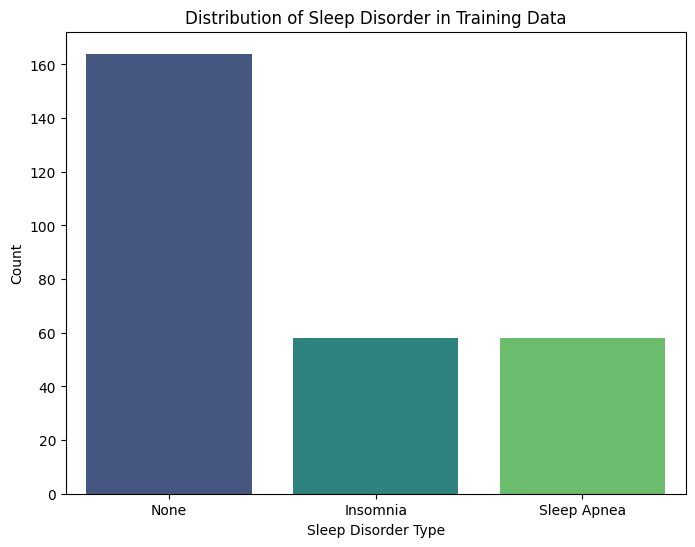

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map the numerical labels back to their original names for better readability in the plot
y_train_labels = y_train.map({0: 'None', 1: 'Insomnia', 2: 'Sleep Apnea'})

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_labels, palette='viridis', hue=y_train_labels, legend=False)
plt.title('Distribution of Sleep Disorder in Training Data')
plt.xlabel('Sleep Disorder Type')
plt.ylabel('Count')
plt.show()


handle inbalance data - SMOTE

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

Check Balance Again

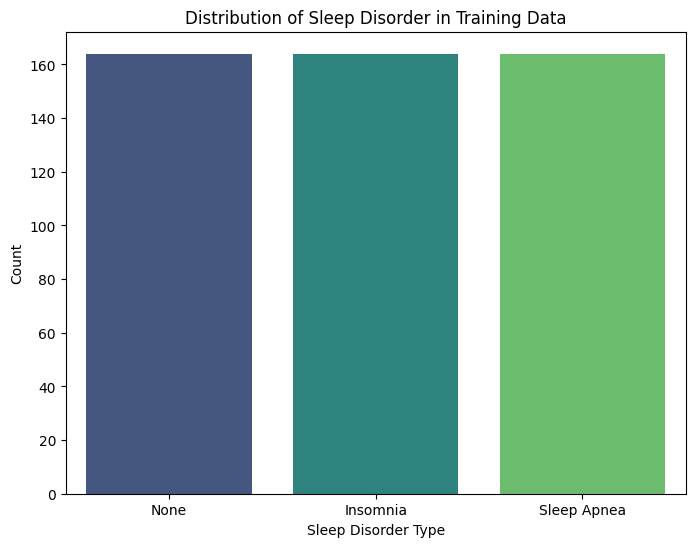

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map the numerical labels back to their original names for better readability in the plot
y_train_labels = y_train.map({0: 'None', 1: 'Insomnia', 2: 'Sleep Apnea'})

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_labels, palette='viridis', hue=y_train_labels, legend=False)
plt.title('Distribution of Sleep Disorder in Training Data')
plt.xlabel('Sleep Disorder Type')
plt.ylabel('Count')
plt.show()


Check shapes

In [57]:
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train_scaled:", y_train.shape)
print("Shape of y_test_scaled:", y_test.shape)

Shape of X_train_scaled: (492, 22)
Shape of X_test_scaled: (94, 22)
Shape of y_train_scaled: (492,)
Shape of y_test_scaled: (94,)


In [27]:
# Check the distribution of y_train and y_test to ensure stratification worked
print("\nDistribution of 'Sleep Disorder Encoded' in y_train:")
display(y_train.value_counts(normalize=True).sort_index())
print("\nDistribution of 'Sleep Disorder Encoded' in y_test:")
display(y_test.value_counts(normalize=True).sort_index())


Distribution of 'Sleep Disorder Encoded' in y_train:


,proportion
Sleep Disorder Encoded,
0,0.333333
1,0.333333
2,0.333333



Distribution of 'Sleep Disorder Encoded' in y_test:


,proportion
Sleep Disorder Encoded,
0,0.585106
1,0.202128
2,0.212766


Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

# Keep original copy BEFORE scaling
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# Create new scaled datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


# Initialize scaler
scaler = StandardScaler()

# Columns to scale (ONLY numerical ones)
numerical_features = [
    'Age',
    'Sleep Duration',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic',
    'Diastolic'
]

# Fit ONLY on training data
X_train_scaled[numerical_features] = scaler.fit_transform(X_train_original[numerical_features])

# Apply SAME transformation to test data
X_test_scaled[numerical_features] = scaler.transform(X_test_original[numerical_features])


Display Scaled Data Set

In [52]:
print("Before Scaling:")
display(X_train_original[numerical_features].head())

print("After Scaling:")
display(X_train_scaled[numerical_features].head())

Before Scaling:


,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
206,43,7.7,90,5,70,8000,130,85
76,33,6.0,30,8,72,5000,125,80
147,39,6.5,40,7,80,4000,132,87
233,44,6.3,45,7,72,6000,130,85
35,31,6.1,30,8,72,5000,125,80


After Scaling:


,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
206,0.138526,0.719415,1.466034,-0.222830,-0.022916,0.732691,0.200896,0.069950
76,-1.029763,-1.454818,-1.416954,1.494394,0.470649,-1.141428,-0.442708,-0.746136
147,-0.328790,-0.815338,-0.936456,0.921986,2.444908,-1.766134,0.458338,0.396385
233,0.255355,-1.071130,-0.696207,0.921986,0.470649,-0.516722,0.200896,0.069950
35,-1.263421,-1.326922,-1.416954,1.494394,0.470649,-1.141428,-0.442708,-0.746136


In [28]:
print(data.isnull().sum())

Gender                             0
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
Heart Rate                         0
Daily Steps                        0
Sleep Disorder                     0
Systolic                           0
Diastolic                          0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Manager                 0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Occupation_Salesperson             0
Occupation_Scientist               0
Occupation_Software Engineer       0
Occupation_Teacher                 0
BMI Category_Normal Weight         0
BMI Category_Obese                 0
BMI Category_Overweight            0
Sleep Disorder Encoded             0
dtype: int64


### 5. Model Training and Evaluation - Logistic Regression (Multi-class)

In [30]:
# Initialize and train the Logistic Regression model for multi-class classification
# 'newton-cg' or 'lbfgs' are suitable for multi_class='multinomial'
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    C=0.5,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

ValueError: Found input variables with inconsistent numbers of samples: [280, 492]

In [ ]:
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Logistic Regression ===")

print("\n--- Train Data ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Precision:", precision_score(y_train, y_train_pred_lr, average='weighted'))
print("Recall:", recall_score(y_train, y_train_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_train, y_train_pred_lr, average='weighted'))

print("\n--- Test Data ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Precision:", precision_score(y_test, y_test_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_lr, average='weighted'))

=== Logistic Regression ===

--- Train Data ---
Accuracy: 0.9214285714285714
Precision: 0.9211616704097907
Recall: 0.9214285714285714
F1 Score: 0.9210717481038317

--- Test Data ---
Accuracy: 0.9042553191489362
Precision: 0.9135350465137699
Recall: 0.9042553191489362
F1 Score: 0.9070850182608611


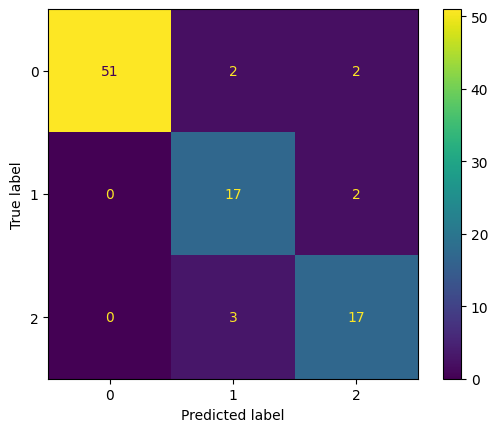

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ['None', 'Insomnia', 'Sleep Apnea']

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()

### 6. Model Training and Evaluation - K-Nearest Neighbors (KNN) (Multi-class)

In [ ]:
# Initialize and train the KNN model for multi-class classification
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
y_train_pred_knn = knn.predict(X_train_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

In [ ]:
print("\n=== KNN ===")

print("\n--- Train Data ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("Precision:", precision_score(y_train, y_train_pred_knn, average='weighted'))
print("Recall:", recall_score(y_train, y_train_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_train, y_train_pred_knn, average='weighted'))

print("\n--- Test Data ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_knn))
print("Precision:", precision_score(y_test, y_test_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred_knn, average='weighted'))


=== KNN ===

--- Train Data ---
Accuracy: 0.9071428571428571
Precision: 0.9074639402884777
Recall: 0.9071428571428571
F1 Score: 0.9062412184658467

--- Test Data ---
Accuracy: 0.8723404255319149
Precision: 0.8836871305582193
Recall: 0.8723404255319149
F1 Score: 0.8763255035199891


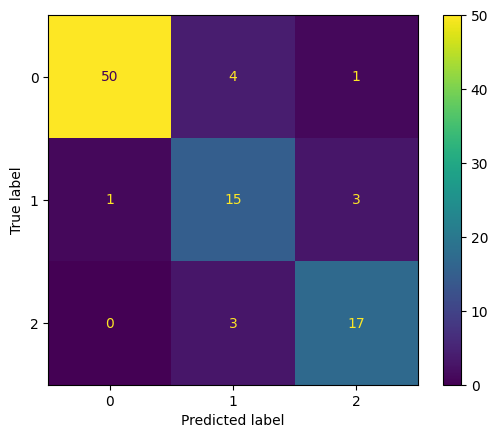

In [ ]:
labels = ['None', 'Insomnia', 'Sleep Apnea']
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()

### 7. Model Comparison and User Prediction Function

### 10. Additional Visualization: ROC Curves

ROC (Receiver Operating Characteristic) curves are useful for visualizing the performance of a classification model across various thresholds. For multi-class classification, we can plot a ROC curve for each class using the one-vs-rest approach, which compares each class against all other classes combined. The Area Under the Curve (AUC) provides a single metric summarizing the ROC curve, with a higher AUC indicating better model performance.

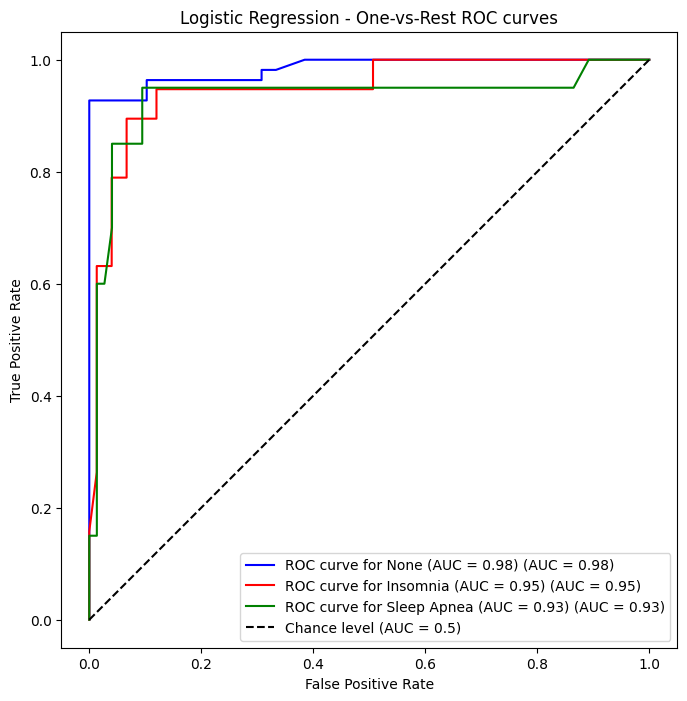

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import LabelBinarizer

# Get probability predictions for Logistic Regression
y_score_lr = lr.predict_proba(X_test_scaled)

# Binarize the true labels for multi-class ROC curve
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'green'] # Assign colors for each class

for i, class_id in enumerate(label_binarizer.classes_):
    # Calculate FPR, TPR, and AUC for each class
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)

    # Use RocCurveDisplay directly with calculated fpr, tpr, and auc
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"ROC curve for {labels[class_id]} (AUC = {roc_auc:.2f})")
    disp.plot(ax=ax, color=colors[i])

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - One-vs-Rest ROC curves")
plt.legend()
plt.show()

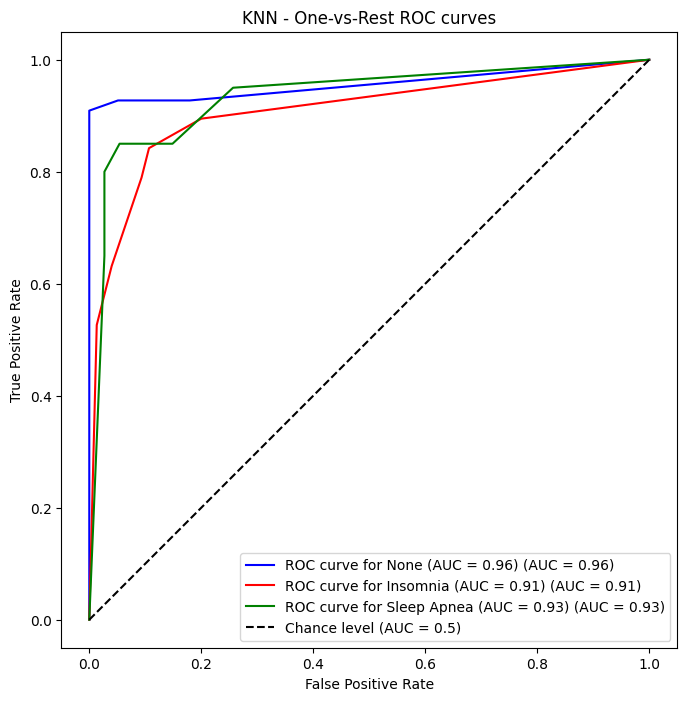

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import LabelBinarizer

# Get probability predictions for KNN
y_score_knn = knn.predict_proba(X_test_scaled)

# Binarize the true labels (if not already done from LR section, or re-run this part)
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'green'] # Assign colors for each class

for i, class_id in enumerate(label_binarizer.classes_):
    # Calculate FPR, TPR, and AUC for each class
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_knn[:, i])
    roc_auc = auc(fpr, tpr)

    # Use RocCurveDisplay directly with calculated fpr, tpr, and auc
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"ROC curve for {labels[class_id]} (AUC = {roc_auc:.2f})")
    disp.plot(ax=ax, color=colors[i])

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN - One-vs-Rest ROC curves")
plt.legend()
plt.show()